# Sliding-Window Machine Learning for Time-Series Incident Prediction

**Objective:**  
Predict whether an incident (abnormal heartbeat) will occur within the next `H` time steps using previous `W` steps of ECG signal.  

**Dataset:** MIT-BIH Arrhythmia Database (record 100)  
**Model:** Balanced Random Forest Classifier  
**Key Steps:** Data loading → Sliding window creation → Feature engineering → Model training → Evaluation → Visualization

In [43]:
!pip install wfdb 

## Import Libraries
We use:
- `wfdb` for ECG signal and annotation loading
- `pandas` and `numpy` for data handling
- `matplotlib` for visualization
- `scikit-learn` and `imblearn` for ML



In [44]:
import wfdb            #used to load ECG/medical waveform data from databases like the MIT-BIH Arrhythmia Database
import pandas as pd    #Used for tables of data
import numpy as np     #Used for numerical calculations and arrays
import matplotlib.pyplot as plt


## Load ECG Record and Annotations
We load record 100 from MIT-BIH and its annotations.  
Annotations indicate normal or abnormal beats.

In [45]:

# Loading ECG signal for patient record 100
record = wfdb.rdrecord('100', pn_dir='mitdb')

annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')   

#Annotations tell things like:
#1.) where heartbeats occur  2.) if a beat is normal or abnormal


# Extract ECG signal
ecg = record.p_signal[:, 0]    #All rows of column 0
fs = record.fs                # sampling frequency


# Build DataFrame
df = pd.DataFrame({
    "time": np.arange(len(ecg)) / fs,
    "ecg": ecg
})

print(' \n' ,df.head())

print(' \n' ,df.tail())

print(' \n' ,df.describe())

 
        time    ecg
0  0.000000 -0.145
1  0.002778 -0.145
2  0.005556 -0.145
3  0.008333 -0.145
4  0.011111 -0.145
 
                time    ecg
649995  1805.541667 -0.075
649996  1805.544444 -0.445
649997  1805.547222 -0.675
649998  1805.550000 -0.765
649999  1805.552778 -1.280
 
                 time            ecg
count  650000.000000  650000.000000
mean      902.776389      -0.306299
std       521.219394       0.193200
min         0.000000      -2.715000
25%       451.388194      -0.390000
50%       902.776389      -0.335000
75%      1354.164583      -0.270000
max      1805.552778       1.435000


## Label Abnormal Beats
- Normal beats: `N`  
- Abnormal beats (incidents): `V, A, E, F, L, R`  
We create a binary `incident` column: 1 if abnormal, 0 if normal.

In [46]:
abnormal = ['V', 'A', 'E', 'F', 'L', 'R']  #Other then N all of them are abnormal beats, hence these are incidents +1

incident = np.zeros(len(ecg), dtype=int)

for samp, sym in zip(annotation.sample, annotation.symbol):
    if sym in abnormal:
        incident[samp] = 1

df["incident"] = incident
incident

array([0, 0, 0, ..., 0, 0, 0])

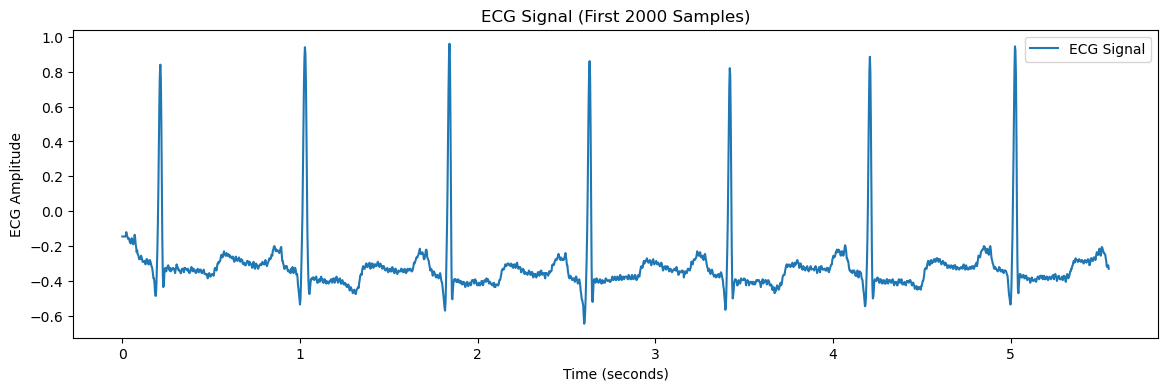

In [61]:
plt.figure(figsize=(14, 4))
plt.plot(df["time"][:2000], df["ecg"][:2000], label="ECG Signal")
plt.title("ECG Signal (First 2000 Samples)")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.legend()
plt.show()

## Create Sliding Windows 
- Window size `W = 360` (1 sec)  
- Prediction horizon `H = 180` (0.5 sec)  
- Future label is 1 if any incident occurs in next `H` samples

In [49]:
def build_windows(signal, labels, W=360, H=180):
    X = []
    y = []

    for i in range(len(signal) - W - H):
        window = signal[i : i + W]
        future_label = np.max(labels[i + W : i + W + H])
        
        X.append(window)
        y.append(future_label)

    return np.array(X), np.array(y)



## Adding simple features 
We append mean, std, max, and min of each window to improve classical ML performance.

In [50]:
def add_stat_features(X):
    mean = np.mean(X, axis=1)
    std = np.std(X, axis=1)
    maximum = np.max(X, axis=1)
    minimum = np.min(X, axis=1)

    stats = np.column_stack([mean, std, maximum, minimum])
    return np.hstack([X, stats])
    

X, y = build_windows(df["ecg"].values, df["incident"].values)
X = add_stat_features(X)


print("X shape:", X.shape)
print("y shape:", y.shape)
print("First window:", X[0][:10])  # first 10 values
print("First label:", y[0])

X shape: (649460, 364)
y shape: (649460,)
First window: [-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]
First label: 0


## Plot Example Window
Visualize the first 360 samples of a window.

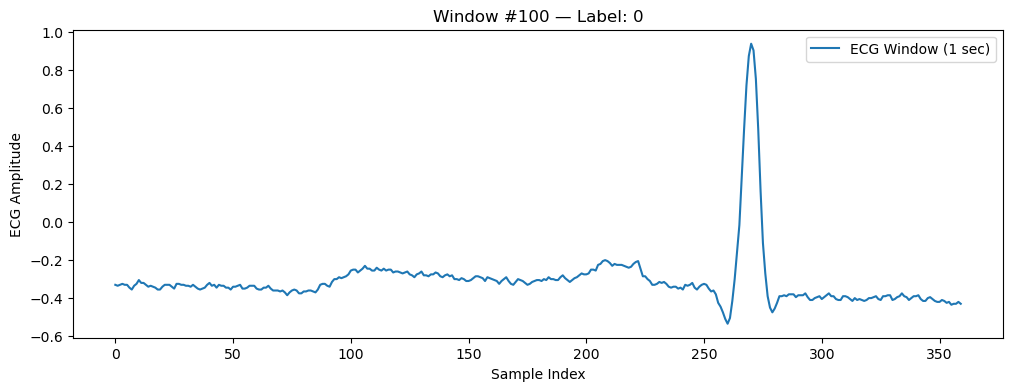

In [51]:
plt.figure(figsize=(12, 4))
plt.plot(X[100][:360], label="ECG Window (1 sec)")
plt.title(f"Window #100 — Label: {y[100]}")
plt.xlabel("Sample Index")
plt.ylabel("ECG Amplitude")
plt.legend()
plt.show()

## Split Data
- 80% train, 20% test  
- No shuffling to preserve time order


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)
print("Training labels distribution:", pd.Series(y_train).value_counts())
print("Testing labels distribution:", pd.Series(y_test).value_counts())

Training samples: (519568, 364)
Testing samples: (129892, 364)
Training labels distribution: 0    515068
1      4500
Name: count, dtype: int64
Testing labels distribution: 0    128272
1      1620
Name: count, dtype: int64



## Standard Scaling
- Scales features to mean 0, std 1

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training sample (first row):")
print(X_train_scaled[0][:10])

Scaled training sample (first row):
[0.85205054 0.85205213 0.85205372 0.85205504 0.85205657 0.85205809
 0.85205987 0.85206146 0.98403836 0.90485505]


In [54]:
num_normal = (y_train == 0).sum()
num_abnormal = (y_train == 1).sum()

print("Normal:", num_normal)
print("Abnormal:", num_abnormal)


Normal: 515068
Abnormal: 4500


## Train Balanced Random Forest
Handles class imbalance in incidents.

In [55]:
from imblearn.ensemble import BalancedRandomForestClassifier

model = BalancedRandomForestClassifier(
    n_estimators=200,
    sampling_strategy="auto"
)

## Model Predictions
- `y_pred`: predicted class
- `y_prob`: predicted probability of incident



In [56]:
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("First 20 predictions:", y_pred[:20])
print("First 20 probabilities:", y_prob[:20])

First 20 predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
First 20 probabilities: [0.195 0.175 0.165 0.165 0.135 0.16  0.135 0.16  0.16  0.18  0.195 0.18
 0.18  0.19  0.19  0.155 0.185 0.195 0.175 0.165]


## Inspect Feature Importance
Shows which parts of the ECG window or statistical features are most relevant.
  

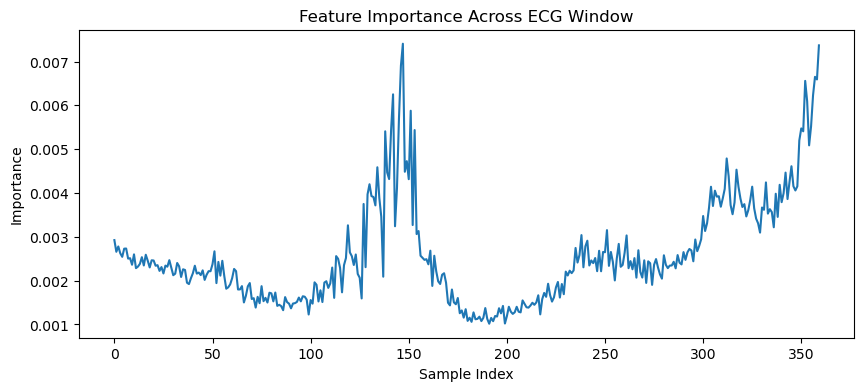

In [57]:
importances = model.feature_importances_

plt.figure(figsize=(10,4))
plt.plot(importances[:360])
plt.title("Feature Importance Across ECG Window")
plt.xlabel("Sample Index")
plt.ylabel("Importance")
plt.show()


## Compute ROC-AUC and PR-AUC
These metrics are appropriate for imbalanced incident prediction tasks.

In [58]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc = roc_auc_score(y_test, y_prob)
pr = average_precision_score(y_test, y_prob)

print("ROC-AUC:", roc)
print("PR-AUC:", pr)

ROC-AUC: 0.8146721708845555
PR-AUC: 0.09313700821481294


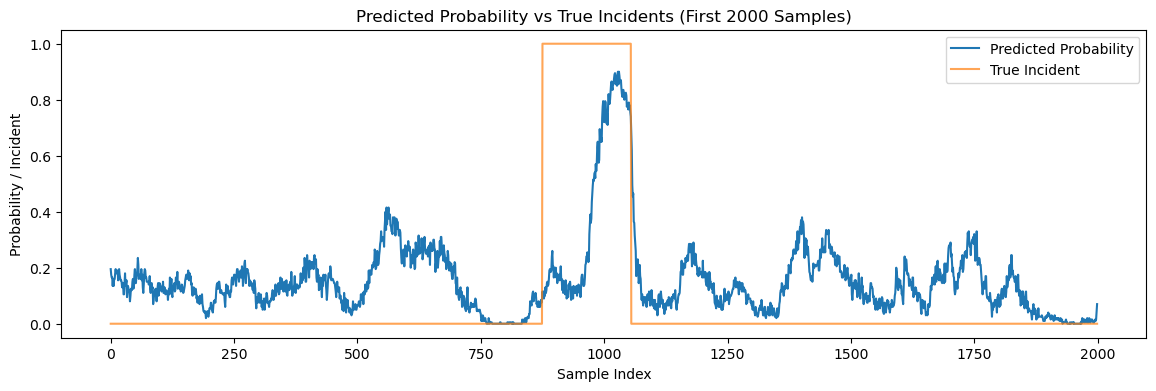

In [59]:
plt.figure(figsize=(14, 4))
plt.plot(y_prob[:2000], label="Predicted Probability")
plt.plot(y_test[:2000], label="True Incident", alpha=0.7)
plt.title("Predicted Probability vs True Incidents (First 2000 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Probability / Incident")
plt.legend()
plt.show()

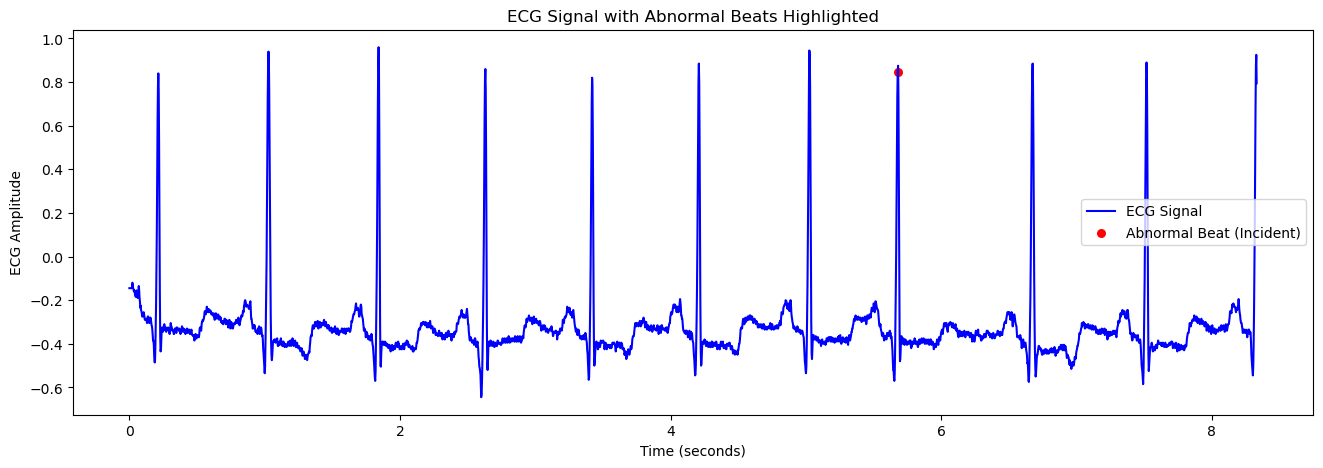

In [60]:
# Select a segment to visualize (first 3000 samples)
segment = df.iloc[:3000]

plt.figure(figsize=(16, 5))
plt.plot(segment["time"], segment["ecg"], label="ECG Signal", color="blue")

# Plot incidents (abnormal beats)
incident_points = segment[segment["incident"] == 1]
plt.scatter(
    incident_points["time"],
    incident_points["ecg"],
    color="red",
    label="Abnormal Beat (Incident)",
    s=30
)

plt.title("ECG Signal with Abnormal Beats Highlighted")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.legend()
plt.show()